<a href="https://colab.research.google.com/github/MalihaRaida/Object-Detection-Experiments/blob/main/CV_for_IRIS_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub opencv-python torch torchvision

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("swoyam2609/casia-iris-interval")

print("Path to dataset files:", path)

100%|██████████| 31.1M/31.1M [00:01<00:00, 24.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/swoyam2609/casia-iris-interval/versions/1


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amnahali/iris-recognition")

print("Path to dataset files:", path)

100%|██████████| 30.4M/30.4M [00:00<00:00, 91.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amnahali/iris-recognition/versions/1


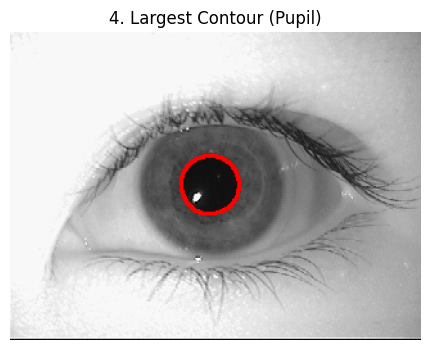

In [4]:
import cv2
import numpy as np
from skimage.filters import gabor, threshold_otsu
from skimage.transform import resize
import matplotlib.pyplot as plt

img = cv2.imread(path+'/MMU-Iris-Database/1/left/aeval1.bmp', cv2.IMREAD_GRAYSCALE)
output = img.copy()
img_blur = cv2.GaussianBlur(img, (7, 7), 1)

_, thresh = cv2.threshold(img_blur, 40, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

max_contour = max(contours, key=cv2.contourArea)
img_max = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_max, [max_contour], -1, (0,0,255), 2)
plt.figure(figsize=(10,4))
plt.title("4. Largest Contour (Pupil)")
plt.imshow(cv2.cvtColor(img_max, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


(x_pupil, y_pupil), pupil_radius = cv2.minEnclosingCircle(max_contour)
center_pupil = (int(x_pupil), int(y_pupil))
pupil_radius = int(pupil_radius)


cv2.circle(output, center_pupil, pupil_radius, (0, 255, 255), 2)



img_canny= cv2.Canny(img, 60, 120, apertureSize=3)
hough_circle = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT,1.5,800,minRadius=30,maxRadius=90)
if hough_circle is not None:
    hough_circle = np.round(hough_circle[0, :]).astype("int")
    for (x, y, radius) in hough_circle:
        cv2.circle(output, (x, y), radius, (255, 0, 0), 2)







In [ ]:
def create_mask(h, w, outer_center, outer_radius, inner_center, inner_radius):
  Y, X = np.ogrid[:h, :w]
  dist_outer = np.sqrt((X - outer_center[0])**2 + (Y - outer_center[1])**2)
  dist_inner = np.sqrt((X - inner_center[0])**2 + (Y - inner_center[1])**2)

    # Pixels inside outer circle but outside inner circle
  mask = (dist_outer <= outer_radius) & (dist_inner > inner_radius)

  return mask

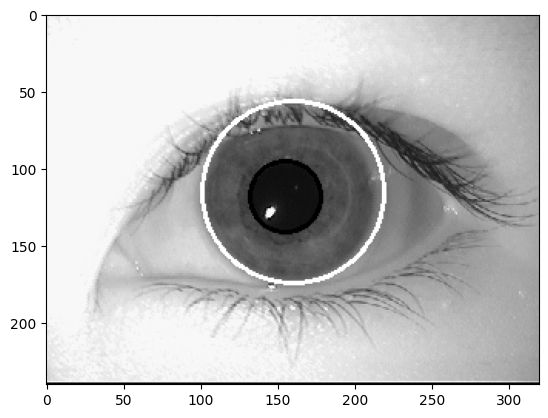

In [ ]:
plt.imshow(output,cmap="grey")

Text(0.5, 1.0, 'Iris Mask')

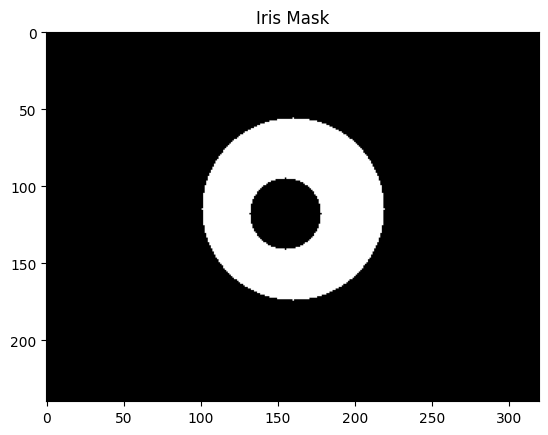

In [ ]:
h,w=output.shape
mask=create_mask(h,w,(x, y), radius,center_pupil,pupil_radius)
plt.imshow(mask, cmap='gray')
plt.title("Iris Mask")


(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

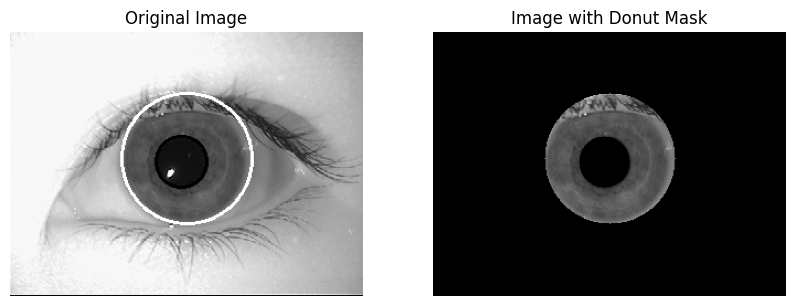

In [ ]:
masked_img=img.copy()
masked_img[~mask] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(output,cmap="grey")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masked_img,cmap="grey")
plt.title("Image with Donut Mask")
plt.axis("off")


(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

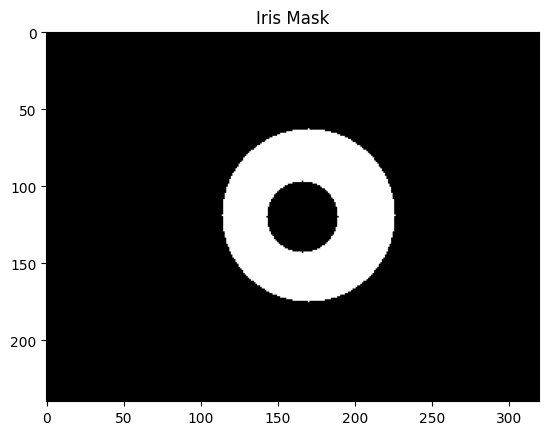

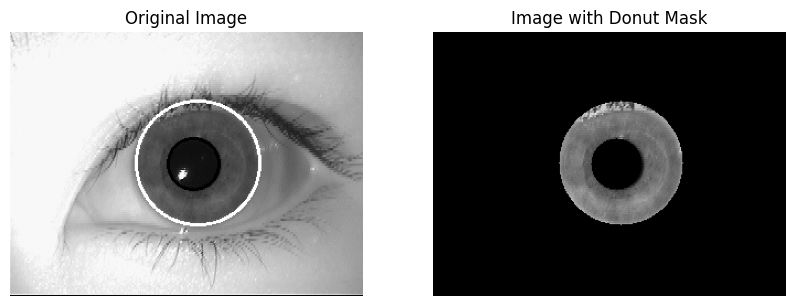

In [ ]:
img_test = cv2.imread(path+'/MMU-Iris-Database/1/left/aeval2.bmp', cv2.IMREAD_GRAYSCALE)
output_test = img_test.copy()
img_blur_test = cv2.GaussianBlur(img_test, (7, 7), 1)

_, thresh = cv2.threshold(img_blur_test, 40, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

max_contour = max(contours, key=cv2.contourArea)
(x_pupil, y_pupil), pupil_radius = cv2.minEnclosingCircle(max_contour)
center_pupil_test = (int(x_pupil), int(y_pupil))
pupil_radius_test = int(pupil_radius)


cv2.circle(output_test, center_pupil_test, pupil_radius_test, (0, 255, 255), 2)



img_canny_test= cv2.Canny(img_test, 60, 120, apertureSize=3)

# plt.imshow(img_canny_test,cmap="grey")

hough_circle_test = cv2.HoughCircles(img_blur_test, cv2.HOUGH_GRADIENT,1.5,800,minRadius=30,maxRadius=90)
if hough_circle_test is not None:
    hough_circle_test = np.round(hough_circle_test[0, :]).astype("int")
    for (x, y, radius) in hough_circle_test:
        cv2.circle(output_test, (x, y), radius, (255, 0, 0), 2)
else:
  print("None")


plt.imshow(output_test,cmap="grey")
h,w=output_test.shape
mask_test=create_mask(h,w,(x, y), radius,center_pupil_test,pupil_radius_test)
plt.imshow(mask_test, cmap='gray')
plt.title("Iris Mask")


masked_img_test=img_test.copy()
masked_img_test[~mask_test] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(output_test,cmap="grey")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masked_img_test,cmap="grey")
plt.title("Image with Donut Mask")
plt.axis("off")

In [ ]:
!pip install opencv-contrib-python

In [ ]:
import numpy as np
import cv2

def _to_float32(img):
    img = img.astype(np.float32)
    if img.max() > 1.5:
        img /= 255.0
    return img

def _ensure_bool_mask(mask, shape=None):
    if mask is None:
        return np.ones(shape, dtype=bool)
    m = mask.astype(bool)
    if shape is not None and m.shape != shape:
        raise ValueError(f"Mask shape {m.shape} != expected {shape}")
    return m


def make_log_gabor_filters(angular_len, n_scales=2, min_wavelength=18.0, mult=2.1, sigma_on_f=0.5):
    u = np.fft.fftfreq(angular_len)
    u[0] = 1e-9
    filters = []

    wavelength = min_wavelength
    for _ in range(n_scales):
        f0 = 1.0 / wavelength
        log_gabor = np.exp(-(np.log(np.abs(u) / f0) ** 2) / (2 * (np.log(sigma_on_f) ** 2)))
        log_gabor[0] = 0.0
        filters.append(log_gabor.astype(np.float32))
        wavelength *= mult

    return filters


def encode_iris(norm_iris, norm_mask=None, n_scales=2, min_wavelength=18.0, mult=2.1, sigma_on_f=0.5):
    """
    norm_iris : (R, T) normalized iris strip, float or uint8
    norm_mask : (R, T) boolean mask (True = valid iris), optional
    Returns:
      code_bits : (R, T, 2*n_scales) boolean array (phase bits: [real>=0, imag>=0] per scale)
      bitmask   : (R, T, 2*n_scales) boolean array (True = reliable bit)
    """
    I = _to_float32(norm_iris)
    R, T = I.shape
    M = _ensure_bool_mask(norm_mask, shape=I.shape)

    # Build filters (along angular dimension T)
    lg_filters = make_log_gabor_filters(T, n_scales=n_scales,
                                        min_wavelength=min_wavelength,
                                        mult=mult, sigma_on_f=sigma_on_f)

    # FFT along angular axis for each radial row
    F = np.fft.fft(I, axis=1)

    # For each scale: filter in frequency, IFFT -> complex response
    responses = []
    for filt in lg_filters:
        # broadcast filter (T,) to (R, T)
        HF = F * filt[None, :]
        resp = np.fft.ifft(HF, axis=1)  # complex
        responses.append(resp)

    # Phase quantization -> 2 bits per scale (sign of real, sign of imag)
    # Stack into shape (R, T, 2*n_scales)
    bits_list = []
    masks_list = []
    for resp in responses:
        real_bit = (resp.real >= 0)
        imag_bit = (resp.imag >= 0)
        # reliability mask: valid pixel in source mask AND sufficient magnitude
        mag = np.abs(resp)
        # Heuristic: treat very low magnitude as unreliable (lambda based on robust stats)
        thr = np.maximum(1e-6, 0.1 * np.median(mag[M]))  # small, data-dependent
        valid = M & (mag >= thr)

        bits_list.extend([real_bit, imag_bit])
        masks_list.extend([valid, valid])

    code_bits = np.stack(bits_list, axis=-1)       # (R, T, 2*n_scales)
    bitmask  = np.stack(masks_list, axis=-1)       # (R, T, 2*n_scales)
    return code_bits.astype(bool), bitmask.astype(bool)


def hamming_distance_rot(codeA, maskA, codeB, maskB, max_shift=8):
    if codeA.shape != codeB.shape:
        raise ValueError("Code shapes must match.")
    R, T, C = codeA.shape
    best_hd = 1.0
    best_shift = 0

    for shift in range(-max_shift, max_shift + 1):
        codeB_s = np.roll(codeB, shift=shift, axis=1)
        maskB_s = np.roll(maskB, shift=shift, axis=1)

        valid = maskA & maskB_s  # (R,T,C)
        valid_count = np.count_nonzero(valid)

        if valid_count == 0:
            continue

        xor = np.logical_xor(codeA, codeB_s) & valid
        hd = np.count_nonzero(xor) / float(valid_count)

        if hd < best_hd:
            best_hd = hd
            best_shift = shift

    if best_hd == 1.0 and np.count_nonzero(maskA) == 0:
        best_hd = 1.0
    return best_hd, best_shift

if __name__ == "__main__":

    norm_iris_A = img
    norm_iris_B = img_test
    mask_A = mask
    mask_B = mask_test


    codeA, bitmaskA = encode_iris(norm_iris_A, mask_A,
                                  n_scales=2, min_wavelength=18.0, mult=2.1, sigma_on_f=0.55)
    codeB, bitmaskB = encode_iris(norm_iris_B, mask_B,
                                  n_scales=2, min_wavelength=18.0, mult=2.1, sigma_on_f=0.55)


    hd, shift = hamming_distance_rot(codeA, bitmaskA, codeB, bitmaskB, max_shift=8)
    print(f"Best masked Hamming distance: {hd:.4f} at rotation shift {shift} columns")

    thresh = 0.4
    print("MATCH" if hd <= thresh else "NON-MATCH")


Best masked Hamming distance: 0.3977 at rotation shift -8 columns
MATCH
